In [1]:
import os
import numpy as np
import torch

from sensorium.utility import get_data, set_random_seed

from utils import load_model_from_config, get_knn_curve, get_ari_curve
import matplotlib.pyplot as plt

random_seed = 42
set_random_seed(random_seed, deterministic=False)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"
# as filenames, we'll select all 7 datasets

filenames = [] 
for file in [
    'static23343-5-17-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static23964-4-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
    'static23656-14-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static21067-10-18-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static22846-10-16-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static27204-5-13-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
]:
    filenames.append(os.path.join(basepath, file))

dataset_fn = "sensorium.datasets.static_loaders"

dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "exclude_eye_position_paths": [
        '/srv/user/polina/sensorium/sensorium/notebooks/data/static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6'
    ],
    "batch_size": 128,
    "scale": 0.25,
}
dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

In [2]:
paths = {
    0.0 : '../training/runs/sigma8/sigma8_seed0',
    0.1 : '../training/runs/entropy/entropy1e-1_seed0',
    1.  : '../training/runs/entropy/entropy1e0_seed0',
    2.  : '../training/runs/entropy/entropy2e0_seed0',
    3.  : '../training/runs/entropy/entropy3e0_seed0',
    5.  : '../training/runs/entropy/entropy5e0_seed0',
    7.  : '../training/runs/entropy/entropy7e0_seed0',
    10. : '../training/runs/entropy/entropy1e1_seed0',
    100.: '../training/runs/entropy/entropy1e2_seed0',
}

models = {}
for sigma, path in paths.items():
    model = load_model_from_config(path, dataloaders, device)
    models[sigma] = model

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [3]:
from sensorium.utility.scores import get_correlations

for sigma, model in models.items():
    print(f'{sigma}: {get_correlations(model, dataloaders['validation'], device=device, per_neuron=False)}')

0.0: 0.4069751501083374
0.1: 0.4069824516773224
1.0: 0.40661048889160156
2.0: 0.4042920470237732
3.0: 0.4030933082103729
5.0: 0.3987218737602234
7.0: 0.39010387659072876
10.0: 0.3470188081264496
100.0: 0.20936539769172668


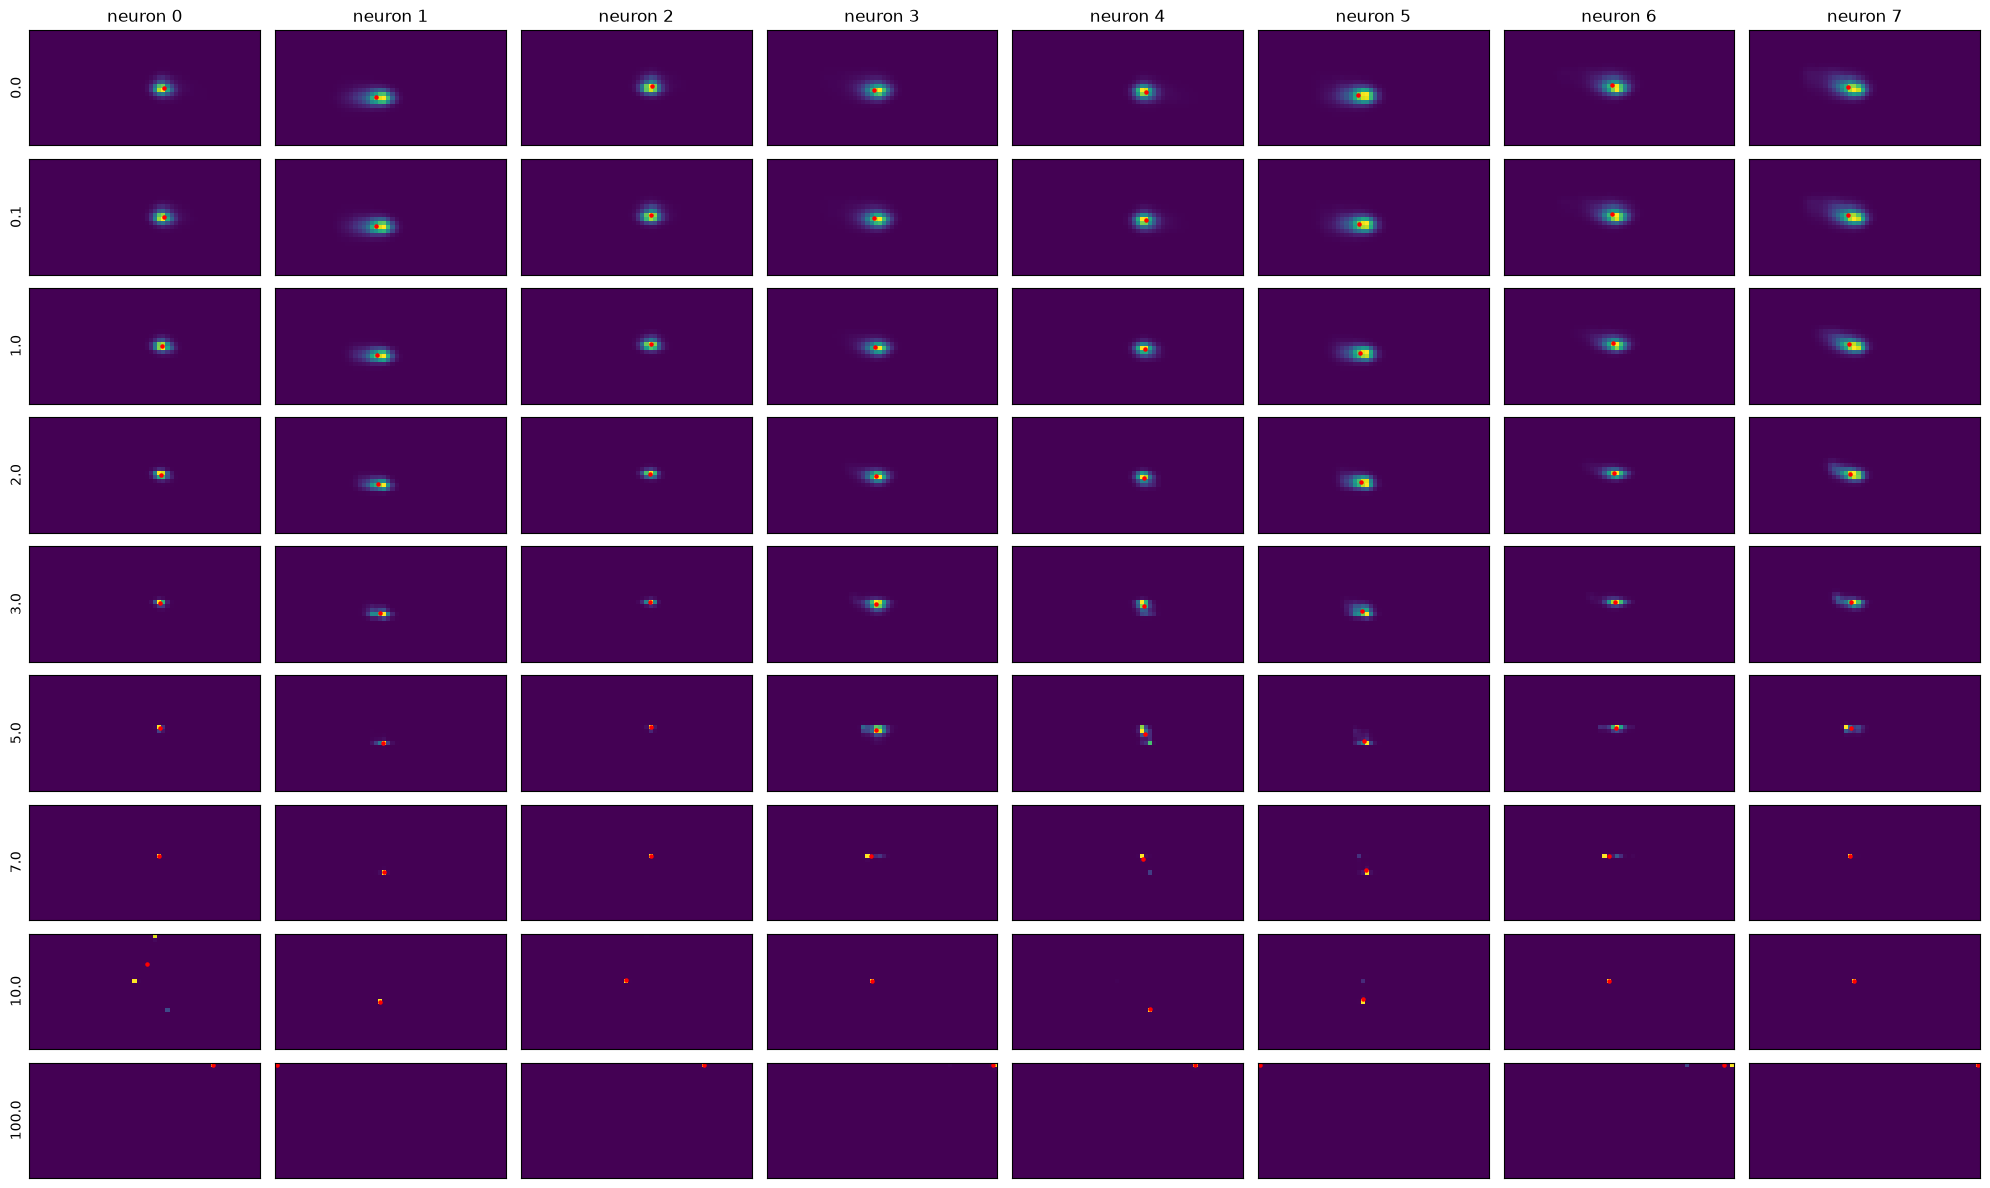

In [10]:
n = 8
fig, axs = plt.subplots(len(models), n, figsize=(20, 12))
neurons = None

for i, (sigma, model) in enumerate(models.items()):    
    spatials = torch.cat([model.readout[k].spatial.detach().cpu() for k in [data_keys[0]]])
    neurons = torch.randperm(spatials.shape[0])[:n] if neurons is None else neurons
    for j in range(n):
        ax = axs[i][j]
        spatial = spatials[neurons[j]]

        h, w = spatial.shape
        y = spatial.sum(dim=1)  # h
        x = spatial.sum(dim=0)  # w

        y_pos = torch.arange(h)
        x_pos = torch.arange(w)

        y_avg = (y_pos * y).sum()
        x_avg = (x_pos * x).sum()

        ax.imshow(spatial)
        ax.scatter(x_avg, y_avg, s=5, color='red')
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.set_title(f'neuron {j}')
        if j == 0:
            ax.set_ylabel(sigma)

plt.tight_layout()

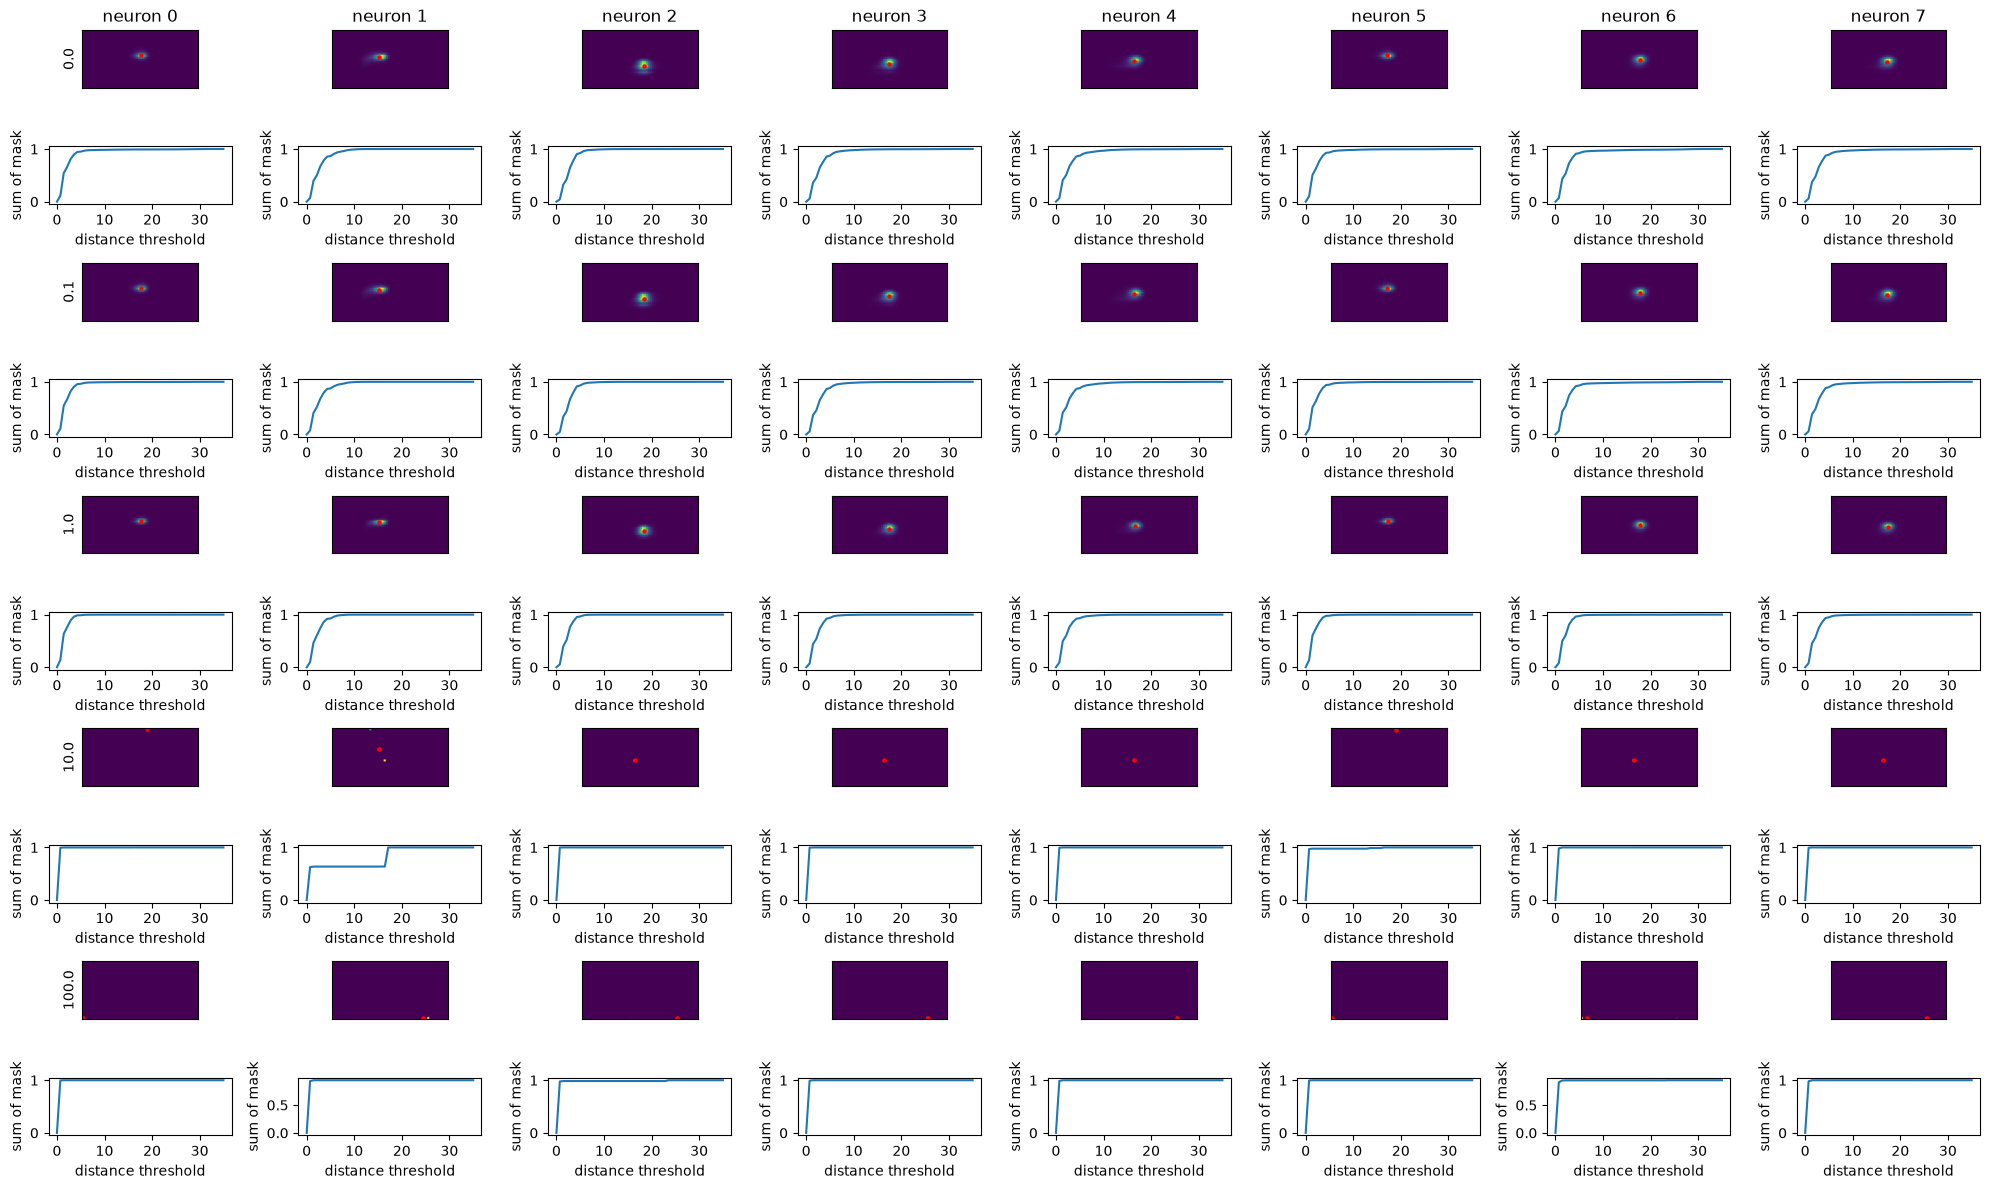

In [12]:
n = 8
fig, axs = plt.subplots(len(models) * 2, n, figsize=(20, 12))
neurons = None

for i, (sigma, model) in enumerate(models.items()):    
    spatials = torch.cat([model.readout[k].spatial.detach().cpu() for k in [data_keys[6]]])
    neurons = torch.randperm(spatials.shape[0])[:n] if neurons is None else neurons
    for j in range(n):
        ax = axs[i * 2][j]
        spatial = spatials[neurons[j]]

        h, w = spatial.shape
        y = spatial.sum(dim=1)  # h
        x = spatial.sum(dim=0)  # w

        y_pos = torch.arange(h)
        x_pos = torch.arange(w)

        y_avg = (y_pos * y).sum()
        x_avg = (x_pos * x).sum()

        ax.imshow(spatial)
        ax.scatter(x_avg, y_avg, s=5, color='red')
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.set_title(f'neuron {j}')
        if j == 0:
            ax.set_ylabel(sigma)

        y_max = y.argmax()
        x_max = x.argmax()

        y_dist = (y_pos - y_max).pow(2)
        x_dist = (x_pos - x_max).pow(2)

        yy, xx = torch.meshgrid(y_dist, x_dist, indexing='ij')
        dists = torch.stack([xx, yy], dim=-1).sum(-1).sqrt()

        thresholds = torch.linspace(0, 35, steps=50)
        volumes = []
        for t in thresholds:
            vol = spatial[dists < t].sum()
            volumes.append(vol)
        
        ax = axs[i * 2 + 1][j]
        ax.plot(thresholds, volumes)
        ax.set_xlabel('distance threshold')
        ax.set_ylabel('sum of mask')

plt.tight_layout()